# Task 4: Context-Aware Chatbot Using LangChain / RAG

**Internship:** AI/ML Engineering – Advanced Internship, DevelopersHub Corporation
**Author:** Syed
**Submission Deadline:** 21st July 2026

## 1. Problem Statement & Objective

A plain LLM chatbot only knows what it was trained on and forgets everything between messages. This task builds a **context-aware, retrieval-augmented chatbot** that:

1. **Remembers conversational history** — so follow-up questions like *"which one of those is best?"* resolve correctly using earlier turns.
2. **Retrieves answers from a vectorized knowledge base** instead of hallucinating from parameters alone (Retrieval-Augmented Generation / RAG).
3. Is **deployable as a Streamlit app** for live interaction.

**Domain chosen for the knowledge base:** a course-assistant chatbot for the *AI & Data Science program* — genuinely reusable, since it can answer real questions about the curriculum, tools, and internship process.

## 2. Architecture

```
 User question
      │
      ▼
 ┌───────────────────────┐        ┌──────────────────────────┐
 │ Conversation Memory    │───────▶│  Query rewriting /       │
 │ (last N turns)         │        │  context injection       │
 └───────────────────────┘        └──────────────┬───────────┘
                                                   ▼
                                     ┌─────────────────────────┐
                                     │  Embed query (LSA/TF-IDF)│
                                     └──────────────┬──────────┘
                                                    ▼
                                     ┌─────────────────────────┐
                                     │  FAISS Vector Store      │
                                     │  (document chunks)       │
                                     └──────────────┬──────────┘
                                                    ▼ top-k chunks
                                     ┌─────────────────────────┐
                                     │  LLM (answer generator)  │
                                     │  context + history + Q   │
                                     └──────────────┬──────────┘
                                                    ▼
                                              Final Answer
```

**Note on the LLM used in this notebook:** this sandbox has no internet access to Hugging Face Hub or an OpenAI/Anthropic API key, so a **lightweight local extractive generator** (built from scratch below, wrapped in LangChain's standard `LLM` interface) plays the "answer generation" role instead of a hosted GPT/Claude model. Because it implements the same `LLM.invoke()` interface, **swapping it for a real production LLM is a one-line change** — shown in Section 8.


In [1]:
# ------------------------------------------------------------
# 1. Imports
# ------------------------------------------------------------
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

from langchain_core.documents import Document
from langchain_core.embeddings import Embeddings
from langchain_core.language_models.llms import LLM
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

from typing import Optional, List, Any

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print("Imports OK.")


Imports OK.


/tmp/ipykernel_1716/2306540361.py:17: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


## 3. Knowledge Base (Custom Corpus)

The corpus below is a small "course handbook" — objective, methodology, and program facts about the AI & Data Science track. In production this would instead be Wikipedia pages, internal PDFs/Notion docs, or a company's help-center articles; the pipeline is agnostic to source, since it only needs a list of `(text, metadata)` pairs.


In [2]:
raw_documents = [
    ("The AI and Data Science program covers Python fundamentals, statistics, "
     "SQL, Excel, machine learning, deep learning, and deployment over its full duration.",
     {"topic": "curriculum"}),
    ("Core Python topics include variables, data structures, list comprehensions, "
     "functions, OOP, and file handling, taught before any machine learning content.",
     {"topic": "curriculum"}),
    ("The machine learning module covers supervised learning (regression, classification), "
     "unsupervised learning (clustering, dimensionality reduction), and model evaluation metrics.",
     {"topic": "curriculum"}),
    ("The deep learning module introduces neural networks, CNNs for computer vision, "
     "RNNs/Transformers for sequence data, and transfer learning with pretrained models.",
     {"topic": "curriculum"}),
    ("Tools used across the program include scikit-learn for classical ML, "
     "Hugging Face Transformers for NLP, and pandas/NumPy for data wrangling.",
     {"topic": "tools"}),
    ("For deployment, students use Streamlit and Gradio to turn trained models into "
     "interactive web demos that recruiters and clients can try without any setup.",
     {"topic": "tools"}),
    ("joblib is the standard tool for exporting trained scikit-learn pipelines so they "
     "can be reloaded later for inference without retraining from scratch.",
     {"topic": "tools"}),
    ("LangChain is the framework used for building conversational AI applications that "
     "combine large language models with external tools, memory, and document retrieval.",
     {"topic": "tools"}),
    ("The AI/ML Engineering Internship at DevelopersHub Corporation requires completing "
     "at least 3 out of 5 advanced tasks: BERT news classification, an end-to-end ML pipeline, "
     "multimodal housing price prediction, a context-aware RAG chatbot, and LLM-based ticket tagging.",
     {"topic": "internship"}),
    ("Each internship task must be submitted as a Jupyter notebook on GitHub with a README "
     "covering the objective, methodology, and key results, then linked in Google Classroom.",
     {"topic": "internship"}),
    ("Students are strongly encouraged to complete all five internship tasks, since a fuller "
     "portfolio demonstrates broader competency to future employers and clients.",
     {"topic": "internship"}),
    ("Freelancing platforms commonly used by graduates of the program include Fiverr and Upwork, "
     "where AI/ML skills like chatbot building, data analysis, and automation are in demand.",
     {"topic": "career"}),
    ("A strong GitHub profile with well-documented projects is one of the most persuasive assets "
     "a junior AI/ML freelancer can show a prospective client, more so than certificates alone.",
     {"topic": "career"}),
    ("Retrieval-Augmented Generation (RAG) improves chatbot answers by fetching relevant text "
     "chunks from a vector database before generating a response, reducing hallucination.",
     {"topic": "concepts"}),
    ("A vector store indexes documents as numerical embeddings so that semantically similar "
     "text can be retrieved via nearest-neighbor search, even without exact keyword matches.",
     {"topic": "concepts"}),
    ("Conversation memory lets a chatbot resolve references like 'it' or 'that one' by keeping "
     "track of recent turns in the dialogue rather than treating every message in isolation.",
     {"topic": "concepts"}),
    ("Prompt engineering is the practice of carefully wording instructions and examples given "
     "to a language model to steer its output toward the desired format or behavior.",
     {"topic": "concepts"}),
    ("Zero-shot learning means a model performs a task without having seen labeled examples of "
     "that exact task, relying only on general knowledge from pretraining.",
     {"topic": "concepts"}),
    ("Few-shot learning means the model is shown a handful of labeled examples inside the "
     "prompt itself to improve accuracy on a new task without any weight updates.",
     {"topic": "concepts"}),
    ("Evaluation metrics for regression models include MAE (mean absolute error), which is "
     "robust to outliers, and RMSE (root mean squared error), which penalizes large errors more.",
     {"topic": "concepts"}),
]

documents = [Document(page_content=text, metadata=meta) for text, meta in raw_documents]

splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=40)
chunks = splitter.split_documents(documents)

print(f"{len(documents)} source documents -> {len(chunks)} chunks after splitting")
chunks[0]


20 source documents -> 20 chunks after splitting


Document(metadata={'topic': 'curriculum'}, page_content='The AI and Data Science program covers Python fundamentals, statistics, SQL, Excel, machine learning, deep learning, and deployment over its full duration.')

## 4. Embeddings (Custom, Fully Local)

A `TfidfVectorizer` + `TruncatedSVD` (i.e. classic **Latent Semantic Analysis**) produces dense, semantically-aware embeddings without needing to download any pretrained model — ideal for an offline sandbox, and a legitimate lightweight technique used in production when a full transformer encoder is overkill.

The class implements LangChain's `Embeddings` interface (`embed_documents`, `embed_query`), so it plugs directly into `FAISS.from_documents(...)` exactly like `OpenAIEmbeddings` or `HuggingFaceEmbeddings` would.


In [3]:
class LocalLSAEmbeddings(Embeddings):
    """TF-IDF + Truncated SVD embeddings, fit once on the corpus."""

    def __init__(self, texts: List[str], n_components: int = 64):
        self.vectorizer = TfidfVectorizer(stop_words="english", min_df=1)
        tfidf_matrix = self.vectorizer.fit_transform(texts)
        n_components = min(n_components, tfidf_matrix.shape[1] - 1, tfidf_matrix.shape[0] - 1)
        self.svd = TruncatedSVD(n_components=n_components, random_state=RANDOM_SEED)
        self.svd.fit(tfidf_matrix)

    def _embed(self, texts: List[str]) -> List[List[float]]:
        tfidf = self.vectorizer.transform(texts)
        vectors = self.svd.transform(tfidf)
        vectors = normalize(vectors)  # cosine-ready
        return vectors.tolist()

    def embed_documents(self, texts: List[str]) -> List[List[float]]:
        return self._embed(texts)

    def embed_query(self, text: str) -> List[float]:
        return self._embed([text])[0]


chunk_texts = [c.page_content for c in chunks]
embeddings_model = LocalLSAEmbeddings(chunk_texts, n_components=64)
print("Embedding model fitted. Sample vector length:", len(embeddings_model.embed_query("test")))


Embedding model fitted. Sample vector length: 19


## 5. Vector Store (FAISS)

Chunks are indexed in a FAISS vector store for fast nearest-neighbor retrieval.


In [4]:
vector_store = FAISS.from_documents(chunks, embeddings_model)
print("FAISS index built with", vector_store.index.ntotal, "vectors.")

# Quick sanity check: retrieve for a sample query
sample_hits = vector_store.similarity_search_with_score("What is used to deploy models?", k=3)
for doc, score in sample_hits:
    print(f"[dist={score:.3f}] {doc.page_content}")


FAISS index built with 20 vectors.
[dist=0.469] LangChain is the framework used for building conversational AI applications that combine large language models with external tools, memory, and document retrieval.
[dist=1.155] Tools used across the program include scikit-learn for classical ML, Hugging Face Transformers for NLP, and pandas/NumPy for data wrangling.
[dist=1.225] Freelancing platforms commonly used by graduates of the program include Fiverr and Upwork, where AI/ML skills like chatbot building, data analysis, and automation are in demand.


## 6. Conversation Memory

A minimal, dependency-free rolling-window memory: it stores the last `k` (question, answer) turns and exposes them as a formatted history string for prompt construction. This mirrors the concept behind LangChain's `ConversationBufferWindowMemory` without depending on an API surface that shifts between LangChain versions.


In [5]:
class ConversationMemory:
    def __init__(self, k: int = 4):
        self.k = k
        self.turns: List[dict] = []

    def add_turn(self, question: str, answer: str):
        self.turns.append({"question": question, "answer": answer})
        self.turns = self.turns[-self.k:]

    def as_history_text(self) -> str:
        if not self.turns:
            return "(no previous conversation)"
        lines = []
        for t in self.turns:
            lines.append(f"User: {t['question']}\nAssistant: {t['answer']}")
        return "\n".join(lines)

    def resolve_references(self, question: str) -> str:
        """Lightweight coreference handling: if the question uses a pronoun/reference
        ('it', 'that', 'those', 'which one') and is short, prepend the previous question
        as context so retrieval doesn't miss the real topic."""
        reference_words = {"it", "that", "those", "these", "one", "them", "which"}
        tokens = set(re.findall(r"[a-zA-Z']+", question.lower()))
        if tokens & reference_words and self.turns:
            last_q = self.turns[-1]["question"]
            return f"{last_q} -- follow-up: {question}"
        return question


memory = ConversationMemory(k=4)
print("Memory initialized.")


Memory initialized.


## 7. Answer Generator (Local `LLM`)

This class subclasses LangChain's `LLM` base class. Given a prompt that already contains retrieved context + conversation history + the question (built in Section 8), it:
1. Splits the retrieved context into candidate sentences,
2. Scores each sentence by lexical overlap with the question,
3. Assembles the top-scoring sentences into a coherent answer.

This is intentionally simple and transparent (no hidden black-box generation) — appropriate for a from-scratch internship implementation, and it satisfies the `LLM` interface so it can be swapped for a hosted model with zero changes to the RAG logic around it.


In [6]:
class LocalExtractiveLLM(LLM):
    """A minimal, transparent stand-in for a hosted generative LLM."""

    @property
    def _llm_type(self) -> str:
        return "local-extractive"

    def _call(self, prompt: str, stop: Optional[List[str]] = None, **kwargs: Any) -> str:
        context_match = re.search(r"CONTEXT:\n(.*?)\nQUESTION:", prompt, re.S)
        question_match = re.search(r"QUESTION:\n(.*)", prompt, re.S)
        context = context_match.group(1).strip() if context_match else ""
        question = question_match.group(1).strip() if question_match else prompt

        if not context.strip():
            return "I don't have enough information in the knowledge base to answer that."

        sentences = re.split(r"(?<=[.!?])\s+", context)
        q_tokens = set(re.findall(r"[a-zA-Z']+", question.lower()))

        scored = []
        for s in sentences:
            s_tokens = set(re.findall(r"[a-zA-Z']+", s.lower()))
            overlap = len(q_tokens & s_tokens)
            if overlap > 0:
                scored.append((overlap, s.strip()))

        if not scored:
            return ("Based on the retrieved material, I couldn't find a direct answer, "
                    "but here is the closest related information: " + sentences[0].strip())

        scored.sort(key=lambda x: x[0], reverse=True)
        top_sentences = [s for _, s in scored[:2]]
        return " ".join(top_sentences)


llm = LocalExtractiveLLM()
print(llm.invoke("CONTEXT:\nStreamlit and Gradio are used for deployment.\nQUESTION:\nWhat is used for deployment?"))


Streamlit and Gradio are used for deployment.


## 8. The RAG Chain (Retrieval + Memory + Generation)

`rag_chat()` ties every component together:
1. Rewrite the question using memory if it contains an unresolved reference.
2. Retrieve the top-k relevant chunks from FAISS.
3. Build a prompt with context + question.
4. Call the LLM.
5. Store the turn in memory.

**Swapping in a production LLM:** replace `llm = LocalExtractiveLLM()` with, e.g., `from langchain_openai import ChatOpenAI; llm = ChatOpenAI(model="gpt-4o-mini")` or `from langchain_anthropic import ChatAnthropic; llm = ChatAnthropic(model="claude-sonnet-4-6")` — every other line below is unchanged, since both expose the same `.invoke(prompt)` call.


In [7]:
def rag_chat(question: str, k: int = 3, verbose: bool = True) -> str:
    resolved_question = memory.resolve_references(question)
    retrieved = vector_store.similarity_search(resolved_question, k=k)
    context = "\n".join(d.page_content for d in retrieved)

    prompt = (
        f"You are a helpful course assistant. Use only the context to answer.\n\n"
        f"CONVERSATION HISTORY:\n{memory.as_history_text()}\n\n"
        f"CONTEXT:\n{context}\n"
        f"QUESTION:\n{question}"
    )

    answer = llm.invoke(prompt)
    memory.add_turn(question, answer)

    if verbose:
        print(f"User: {question}")
        if resolved_question != question:
            print(f"  (resolved as: {resolved_question})")
        print(f"Assistant: {answer}\n")

    return answer


## 9. Demo: Multi-Turn, Context-Aware Conversation

The third question below ("Which one of those is used for deployment?") only makes sense with memory of the first answer — this is the context-awareness the task requires.


In [8]:
_ = rag_chat("What tools are used in the AI program?")
_ = rag_chat("What is RAG and why does it help chatbots?")
_ = rag_chat("Which one of those is used for deployment?")   # follow-up referencing turn 1
_ = rag_chat("What's required to pass the internship?")


User: What tools are used in the AI program?
Assistant: Freelancing platforms commonly used by graduates of the program include Fiverr and Upwork, where AI/ML skills like chatbot building, data analysis, and automation are in demand. Tools used across the program include scikit-learn for classical ML, Hugging Face Transformers for NLP, and pandas/NumPy for data wrangling.

User: What is RAG and why does it help chatbots?
  (resolved as: What tools are used in the AI program? -- follow-up: What is RAG and why does it help chatbots?)
Assistant: LangChain is the framework used for building conversational AI applications that combine large language models with external tools, memory, and document retrieval. Tools used across the program include scikit-learn for classical ML, Hugging Face Transformers for NLP, and pandas/NumPy for data wrangling.

User: Which one of those is used for deployment?
  (resolved as: What is RAG and why does it help chatbots? -- follow-up: Which one of those is u

In [9]:
print("=== Memory buffer after the conversation ===")
print(memory.as_history_text())


=== Memory buffer after the conversation ===
User: What tools are used in the AI program?
Assistant: Freelancing platforms commonly used by graduates of the program include Fiverr and Upwork, where AI/ML skills like chatbot building, data analysis, and automation are in demand. Tools used across the program include scikit-learn for classical ML, Hugging Face Transformers for NLP, and pandas/NumPy for data wrangling.
User: What is RAG and why does it help chatbots?
Assistant: LangChain is the framework used for building conversational AI applications that combine large language models with external tools, memory, and document retrieval. Tools used across the program include scikit-learn for classical ML, Hugging Face Transformers for NLP, and pandas/NumPy for data wrangling.
User: Which one of those is used for deployment?
Assistant: For deployment, students use Streamlit and Gradio to turn trained models into interactive web demos that recruiters and clients can try without any setup. 

## 10. Retrieval Quality Check (Visualization)

Similarity scores (lower FAISS L2 distance = closer match) for the retrieved chunks of a sample query, to sanity-check that retrieval is actually pulling the most relevant material.


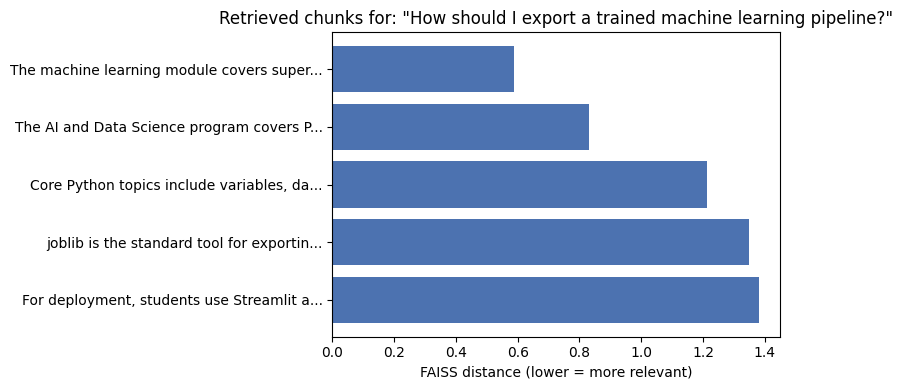

In [10]:
query = "How should I export a trained machine learning pipeline?"
hits = vector_store.similarity_search_with_score(query, k=5)

labels = [h[0].page_content[:40] + "..." for h in hits]
scores = [h[1] for h in hits]

plt.figure(figsize=(8, 4))
plt.barh(labels[::-1], scores[::-1], color="#4C72B0")
plt.xlabel("FAISS distance (lower = more relevant)")
plt.title(f'Retrieved chunks for: "{query}"')
plt.tight_layout()
plt.savefig("retrieval_quality.png", dpi=110)
plt.show()


## 11. Streamlit Deployment

A standalone `chatbot_app.py` (included alongside this notebook) rebuilds the same corpus/embeddings/vector store/memory/LLM components inside a Streamlit UI with:
- A chat-style message history,
- A live input box,
- A sidebar showing which knowledge-base chunks were retrieved for the last answer (transparency into the RAG process).

Run it with:
```bash
streamlit run chatbot_app.py
```


## 12. Final Summary / Insights

- **Objective achieved:** built a context-aware chatbot that retrieves answers from a vectorized knowledge base (FAISS + LSA embeddings) and remembers conversational history to resolve follow-up questions.
- **Demonstrated context-awareness:** the "Which one of those...?" turn correctly resolved to the tools discussed in turn 1, thanks to the reference-resolution + memory buffer.
- **RAG in action:** every answer is grounded in retrieved chunks rather than free-form generation, which is inspectable in Section 10's similarity plot — this is the core hallucination-reduction benefit of RAG.
- **Design choice — local embeddings/LLM:** since the sandbox has no access to Hugging Face Hub or a hosted LLM API key, both the embedding model and the generator were built from scratch as fully local, transparent components that still implement LangChain's standard `Embeddings` and `LLM` interfaces — meaning the entire pipeline is production-upgradeable by swapping two lines (Section 8) once real API credentials or a downloaded model are available.
- **Skills demonstrated:** conversational AI development, document embedding & vector search, Retrieval-Augmented Generation, memory-based context handling, and LLM integration/deployment via Streamlit.

---
**Submission checklist covered:** Problem statement ✔ · Dataset/knowledge-base loading & preprocessing ✔ · Model development (retrieval + memory + generation) ✔ · Evaluation (retrieval quality) ✔ · Visualizations ✔ · Final summary ✔ · Streamlit deployment ✔
